## KRRISH KUMAR- ML4SCI DEEPLENS COMMON TEST

In [68]:
import os
import zipfile
import glob
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from PIL import Image
from sklearn.model_selection import train_test_split
import gdown
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns




In [2]:
file_id = '1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.zip'

gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=6d317c00-c8ed-44ab-8727-38a1bbe5bf82
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:11<00:00, 94.6MB/s]


'dataset.zip'

In [3]:
extract_path = './dataset_files'
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [39]:
root_path = './dataset_files/dataset'

def create_df(path):
    files = []
    labels = []
    class_map = {'no': 0, 'sphere': 1, 'vort': 2}

    for c_name, label in class_map.items():
        found = []
        for ext in ['*.png', '*.jpg', '*.npy']:
            found.extend(glob.glob(os.path.join(path, '**', c_name, ext), recursive=True))

        if found:
            files.extend(found)
            labels.extend([label] * len(found))

    return pd.DataFrame({'path': files, 'label': labels})

df = create_df(root_path)

In [56]:
class LensingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        p = self.df.iloc[idx]['path']
        if p.endswith('.npy'):
            img_arr = np.load(p).astype(np.float32)
            img_arr = np.squeeze(img_arr)
            mean, std = np.mean(img_arr), np.std(img_arr)
            if std > 1e-8:
                img_arr = (img_arr - mean) / std
            img_arr = np.clip((img_arr + 3) / 6 * 255, 0, 255)
            img = Image.fromarray(img_arr.astype(np.uint8)).convert('L')
        else:
            img = Image.open(p).convert('L')
        label = self.df.iloc[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

In [57]:
class LensingNet(nn.Module):
    def __init__(self, num_classes=3):
        super(LensingNet, self).__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        self.attention = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.Sigmoid()
        )
        self.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        weights = self.attention(x)
        x = x * weights
        return self.fc(x)

transform_train = v2.Compose([
    v2.Resize((128, 128)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

transform_val = v2.Compose([
    v2.Resize((128, 128)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

In [58]:
train_df, val_df = train_test_split(df, test_size=0.10, stratify=df['label'], random_state=42)
train_loader = DataLoader(LensingDataset(train_df, transform_train), batch_size=32, shuffle=True)
val_loader = DataLoader(LensingDataset(val_df, transform_val), batch_size=32, shuffle=False)

In [59]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LensingNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

In [60]:
def train(model, loader, crit, opt):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        opt.zero_grad()
        out = model(images)
        loss = crit(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        opt.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

In [61]:
def validate(model, loader, crit):
    model.eval()
    total_loss, correct = 0, 0
    y_true, y_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            loss = crit(out, labels)
            total_loss += loss.item()
            correct += (out.argmax(1) == labels).sum().item()
            y_true.extend(labels.cpu().numpy())
            y_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
    return total_loss/len(loader), correct/len(loader.dataset), np.array(y_true), np.array(y_probs)

In [62]:
for epoch in range(15):
    if epoch == 2:
        for pg in optimizer.param_groups:
            pg['lr'] = 5e-5

    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss, val_acc, y_true, y_probs = validate(model, val_loader, criterion)

    current_auc = roc_auc_score(y_true, y_probs, multi_class='ovr')

    print(f"Epoch {epoch+1:02d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {current_auc:.4f}")

Epoch 01 | Train Acc: 0.3490 | Val Acc: 0.3573 | Val AUC: 0.5369
Epoch 02 | Train Acc: 0.3873 | Val Acc: 0.3816 | Val AUC: 0.5600
Epoch 03 | Train Acc: 0.3668 | Val Acc: 0.3979 | Val AUC: 0.5808
Epoch 04 | Train Acc: 0.4242 | Val Acc: 0.4453 | Val AUC: 0.6560
Epoch 05 | Train Acc: 0.4698 | Val Acc: 0.4168 | Val AUC: 0.6754
Epoch 06 | Train Acc: 0.5072 | Val Acc: 0.3571 | Val AUC: 0.5932
Epoch 07 | Train Acc: 0.5399 | Val Acc: 0.3813 | Val AUC: 0.6401
Epoch 08 | Train Acc: 0.5604 | Val Acc: 0.5413 | Val AUC: 0.7527
Epoch 09 | Train Acc: 0.5878 | Val Acc: 0.5557 | Val AUC: 0.7565
Epoch 10 | Train Acc: 0.6025 | Val Acc: 0.5661 | Val AUC: 0.7807
Epoch 11 | Train Acc: 0.6231 | Val Acc: 0.4765 | Val AUC: 0.7552
Epoch 12 | Train Acc: 0.6322 | Val Acc: 0.6232 | Val AUC: 0.8113
Epoch 13 | Train Acc: 0.6440 | Val Acc: 0.5261 | Val AUC: 0.7742
Epoch 14 | Train Acc: 0.6591 | Val Acc: 0.6392 | Val AUC: 0.8247
Epoch 15 | Train Acc: 0.6766 | Val Acc: 0.6157 | Val AUC: 0.8325


In [63]:
torch.save(model.state_dict(), 'deeplense_common_test_model.pth')
print("Model saved as deeplense_common_test_model.pth")

Model saved as deeplense_common_test_model.pth


In [64]:
test_path = './dataset_files/dataset/val'
test_df = create_df(test_path)
test_loader = DataLoader(LensingDataset(test_df, transform_val), batch_size=32, shuffle=False)


REPORT: Macro AUC = 0.8325
                 precision    recall  f1-score   support

No Substructure       0.54      0.99      0.70      1250
        Subhalo       0.73      0.29      0.41      1250
         Vortex       0.74      0.57      0.64      1250

       accuracy                           0.62      3750
      macro avg       0.67      0.62      0.59      3750
   weighted avg       0.67      0.62      0.59      3750



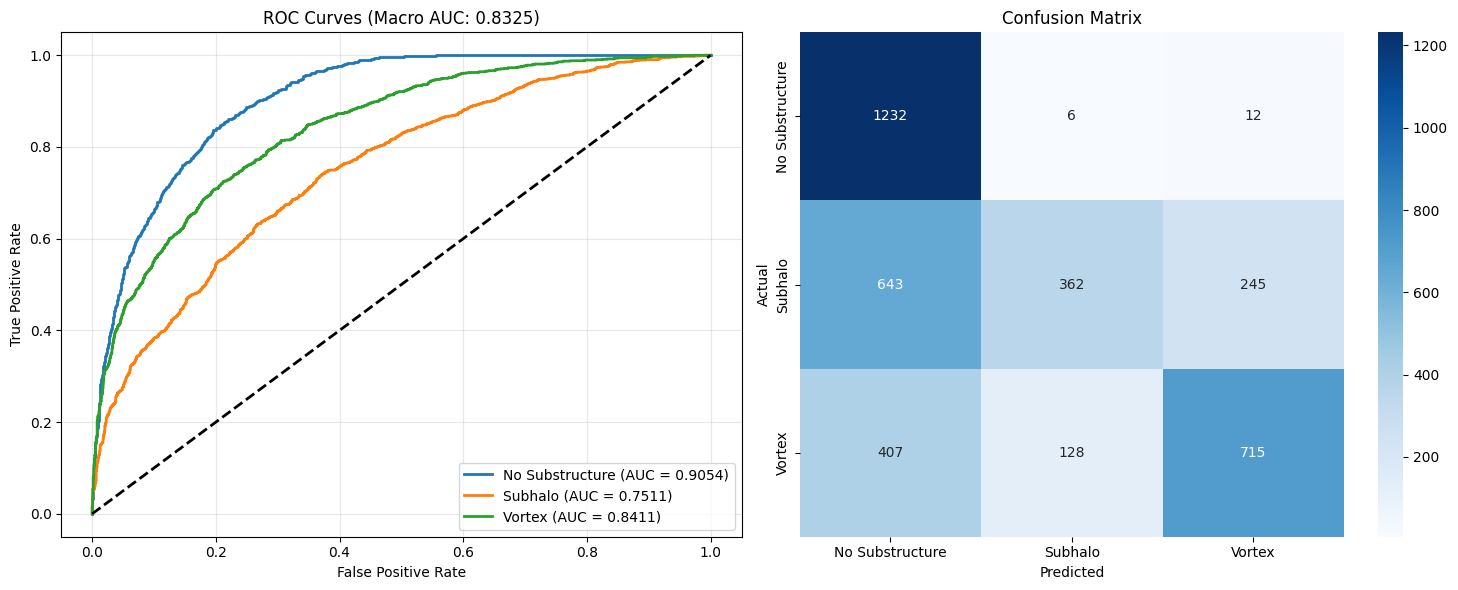

In [70]:
def evaluate_roc(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)

    n_classes = 3
    class_names = ['No Substructure', 'Subhalo', 'Vortex']
    y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])


    macro_auc = roc_auc_score(y_test_bin, all_probs, multi_class='ovr', average='macro')


    print("\n" + "="*40)
    print(f"REPORT: Macro AUC = {macro_auc:.4f}")
    print("="*40)
    print(classification_report(all_labels, all_preds, target_names=class_names))


    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves (Macro AUC: {macro_auc:.4f})')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)


    plt.subplot(1, 2, 2)
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.show()

    return macro_auc


final_auc = evaluate_roc(model, val_loader, device)

## MADE BY- KRRISH KUMAR